In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import find_peaks
import matplotlib.patches as patches

plt.style.use(r"C:\UserData\z003zh2j\OneDrive - Siemens AG\Documents\plot\matlab.mplstyle")

In [ ]:
UR = np.genfromtxt(r"S:\1.FILE\ern\greiner-ern-abr-totak-ko.csv", delimiter=',', skip_header=0)

tt = UR[: , 0]/1e6
a = UR[: , 1]/1e3
b = UR[: , 2]/1e3
#r = UR[: , 3]/1e3

Vypočítané fázové posuny pro jednotlivá okna:
-112.42374829132402 -90.41291220928174 -60.73984610474591


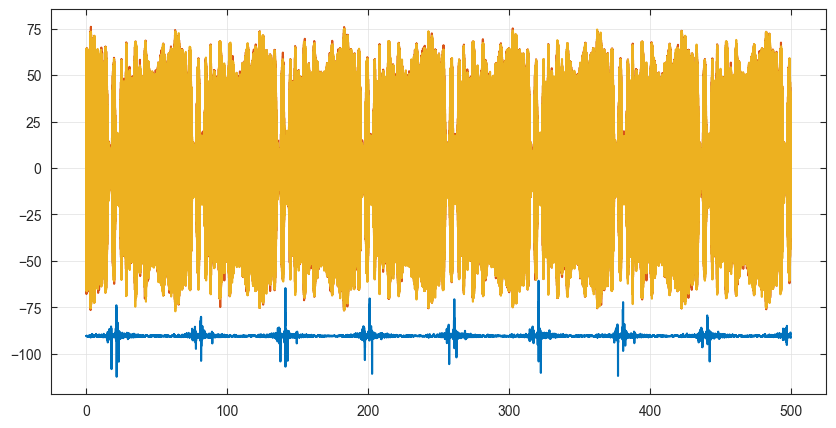

In [43]:

# Simulace dat (např. 1000 vzorků naměřeného signálu a reference)
t = tt
namerena_data = b
referencni_data = a

velikost_okna = 83
pocet_oken = len(namerena_data) // velikost_okna

# Předalokujeme si NumPy array pro výsledky (čísla)
vysledne_faze = np.zeros(pocet_oken)

def spocitej_fazi_fft(signal, reference):
    # Provedeme FFT
    fft_sig = np.fft.fft(signal)
    fft_ref = np.fft.fft(reference)

    # Najdeme index nejvyšší harmonické (vynecháme DC složku na indexu 0)
    idx = np.argmax(np.abs(fft_sig[1:])) + 1

    # Spočítáme fázi v radiánech
    faze_sig = np.angle(fft_sig[idx])
    faze_ref = np.angle(fft_ref[idx])

    # Rozdíl fází převedený na stupně
    rozdil_fazi_rad = faze_sig - faze_ref
    rozdil_fazi_deg = np.degrees(rozdil_fazi_rad)

    # Normalizace do rozsahu -180 až 180 stupňů
    return (rozdil_fazi_deg + 180) % 360 - 180

# For loop procházející data po 83 vzorcích
for i in range(pocet_oken):
    start = i * velikost_okna
    konec = start + velikost_okna

    # Výřez (okno) dat
    okno_sig = namerena_data[start:konec]
    okno_ref = referencni_data[start:konec]

    # Výpočet fáze (zvolte metodu 1 nebo 2)
    vysledne_faze[i] = spocitej_fazi_fft(okno_sig, okno_ref)

print("Vypočítané fázové posuny pro jednotlivá okna:")
print(np.min(vysledne_faze),np.mean(vysledne_faze),np.max(vysledne_faze))
TT=tt[::83]
plt.figure(figsize=(10, 5))
plt.plot(TT[:len(vysledne_faze)],vysledne_faze)
plt.plot(tt,a*200)
plt.plot(tt,b*200)
#plt.xlim(0,10)
plt.show()

In [ ]:
def test(signal):
    global vysledek

    if np.mean(signal) >= (0.05 * np.max(signal)):
        vysledek=("KO! DC offset > 5% Amp")
    else:
        vysledek=("DC offset OK")

test(a)
print("sin A -", vysledek)
test(b)
print("sin B -", vysledek)
print(np.mean(a))
print(np.mean(b))

sin A - DC offset OK
sin B - DC offset OK
-0.003405792861088424
-0.004719775139495882


sin A - KO! DC offset > 5% Amp
sin B - KO! DC offset > 5% Amp


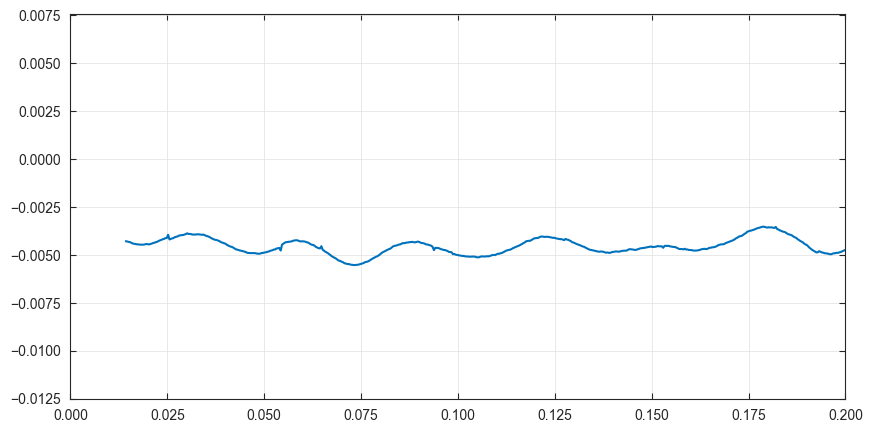

-0.0116, 0.0066


In [ ]:
import pandas as pd

def test(signal):
    velikost_okna = 83 

    # 1. Změříme kolísavý offset (vyhladíme sinusovku)
    kolisavy_offset = pd.Series(signal).rolling(window=velikost_okna, center=True).mean()
    global vysledek
    # if abs(kolisavy_offset) >= (0.05 * np.max(abs(signal))):
    #     vysledek=("KO! DC offset > 5% Amp")
    # else:
    #     vysledek=("DC offset OK")

    # upravit tu podminku aby to fungovaolo a pak to dat do jednoho vyhodnocovacií funkce
    return(kolisavy_offset)

k_o_a = test(a)
print("sin A -", vysledek)
k_o_b = test(b)
print("sin B -", vysledek)

plt.figure(figsize=(10, 5))
plt.plot(tt,k_o_a )
plt.xlim(0, 0.2)
plt.show()
print(f"{np.min(k_o_a ):.4f}, {np.max(k_o_a ):.4f}")



Vpp Signálu a mimo normu: 0.632 V
Vpp Signálu b mimo normu: 0.633 V
Vpp Signálu a mimo normu: 0.638 V
Vpp Signálu b mimo normu: 0.638 V
Vpp Signálu a mimo normu: 0.654 V
...

Měření:      Rel. rozdíl     Amp. sig_a      Amp. sig_b     
---------------------------------------------------------
Mean         1.11 %          0.47 V          0.47 V         
Min          0.00 %          0.01 V          0.01 V         
Max          68.45 %         0.76 V          0.76 V         
Vyhodnoceni: NOK



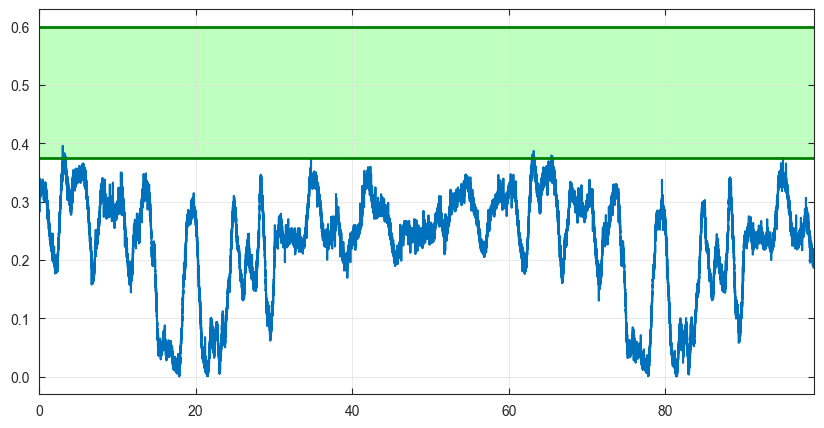

In [40]:
def analyze_signals(sig_1, sig_2,window_size,jmeno):
    lim_min, lim_max = 0.75, 1.2

    # 1. Inicializace seznamů pro ukládání výsledků
    rel_differences = []
    match_conditions = []
    con_v_1 = []
    con_v_2 = []
    vpp_l1 = []
    vpp_l2 = []
    X = []
   
    q=0

    for i in range(0, len(sig_1), window_size):
        X.append(i)
        chunk_1 = sig_1[i:i+window_size]
        chunk_2 = sig_2[i:i+window_size]
        if len(chunk_1) < window_size: break # Konec dat
        
        vpp_1 = np.ptp(chunk_1)
        vpp_2 = np.ptp(chunk_2)

        vpp_l1.append(vpp_1)
        vpp_l2.append(vpp_2)
        
        cond_vpp_1 = lim_min <= vpp_1 <= lim_max
        cond_vpp_2 = lim_min <= vpp_2 <= lim_max
        
        relative_difference = abs(vpp_1 - vpp_2) / vpp_1
        cond_amplitude_match = relative_difference <= 0.10
        
        # 2. Uložení hodnot z aktuálního okna
        rel_differences.append(relative_difference)
        match_conditions.append(cond_amplitude_match)
        
        # Vypíšeme chyby průběžně, pokud signál nesplňuje normu Vpp
        if not cond_vpp_1 and q < 5:
            print(f"Vpp Signálu {jmeno[0]} mimo normu: {vpp_1:.3f} V")
            con_v_1.append(False)
            q+=1
        if not cond_vpp_2 and q < 5:
            print(f"Vpp Signálu {jmeno[1]} mimo normu: {vpp_2:.3f} V")
            con_v_2.append(False)
            q+=1
    if q == 5:
            print("...")
    if q == 0:
        print("Vpp OK")
    print()
    # 3. Převod na NumPy arrays
    arr_diff = np.array(rel_differences) * 100  # převod na procenta rovnou
    arr_match = np.array(match_conditions)

    # 4. Výpočet statistik
    mean_diff = np.mean(arr_diff)
    min_diff = np.min(arr_diff)
    max_diff = np.max(arr_diff)

    mean_vpp_l1 = np.mean(vpp_l1)
    min_vpp_l1 = np.min(vpp_l1)
    max_vpp_l1 = np.max(vpp_l1)
    
    mean_vpp_l2 = np.mean(vpp_l2)
    min_vpp_l2 = np.min(vpp_l2)
    max_vpp_l2 = np.max(vpp_l2)

    #all_matched = "OK" if np.all(arr_match) == True else "NOK"
    all_matched = "OK" if np.all(arr_match) and np.all(cond_vpp_1) and np.all(cond_vpp_2) else "NOK"

    # 5. Výpis výsledků

    # Definice šablony pro řádek: první sloupec 12 znaků, ostatní 15 znaků
    row_format = "{:<12} {:<15} {:<15} {:<15}"

    # Vypsání hlavičky
    print(row_format.format("Měření:", "Rel. rozdíl", f"Amp. sig_{jmeno[0]}", f"Amp. sig_{jmeno[1]}"))
    print("-" * 57) # Oddělovací čára

    # Vypsání dat
    print(row_format.format("Mean", f"{mean_diff:.2f} %", f"{mean_vpp_l1:.2f} V", f"{mean_vpp_l2:.2f} V"))
    print(row_format.format("Min", f"{min_diff:.2f} %", f"{min_vpp_l1:.2f} V", f"{min_vpp_l2:.2f} V"))
    print(row_format.format("Max", f"{max_diff:.2f} %", f"{max_vpp_l1:.2f} V", f"{max_vpp_l2:.2f} V"))
    print("=" * 57) # Oddělovací čára
    print(f"Vyhodnoceni: {all_matched}\n")

    polomer = np.sqrt(a**2+b**2)

    plt.figure(figsize=(10, 5))
    plt.plot(tt,polomer)
    plt.hlines(0.75/2,0,tt[-1]//5,color = 'g',lw = 2)
    plt.hlines(1.2/2,0,tt[-1]//5,color = 'g', lw = 2)
    plt.xlim(0,tt[-1]//5)

    obdelnik = patches.Rectangle((0, 0.75/2),tt[-1]//5 ,1.2/2-0.75/2 , edgecolor='none', facecolor='lime', alpha=0.25, linewidth=1)
    os = plt.gca()
    os.add_patch(obdelnik)
    plt.show()
    

# Spuštění funkce
analyze_signals(a, b,83,"ab")
#analyze_signals(c, d,315789,"cd")